# Telco Customer Churn: Logistic Regression in R

## Overview
This notebook develops a logistic regression model to predict customer churn for a telecommunications company, using the IBM Telco Customer Churn dataset (~7,000 customers, 20 features). The full pipeline covers exploratory analysis, data preparation, model training, stepwise refinement, and evaluation.

Dataset source: IBM Telco Customer Churn via Kaggle — a real-world telco dataset widely used for churn modelling.
From https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data


#### Content

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

* Customers who left within the last month – the column is called Churn
* Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
* Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
* Demographic info about customers – gender, age range, and if they have partners and dependents

#### Key result 
The final model achieves an AUC of ~0.85 on the test set, correctly identifying churners at a rate substantially above chance. The strongest drivers of churn are contract type, tenure, internet service type, and monthly charges — findings with direct business implications.


# 1. Import libraries

In [ ]:
# Core modelling and evaluation
library(caret)
library(car)
library(pROC)

# Visualisation
library(ggplot2)
library(ggcorrplot)
library(ggstatsplot)

# Data manipulation
library(dplyr)
library(tidyr)

# Hosmer-Lemeshow test
library(ResourceSelection)

# 2. Data loading

The dataset contains **7,043 rows and 21 columns**, loaded without type inference (`stringsAsFactors = FALSE`) to retain control over factor 
conversion in later steps.

In [3]:
raw <- read.csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv", stringsAsFactors = FALSE)
head(raw,3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,⋯,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,⋯,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,⋯,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,⋯,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
dim(raw)#7043   21

[1] 7043   21

# 3. Data understanding

A quick inspection confirms the expected structure: one customer identifier (`customerID`), one binary target (`Churn`), three continuous predictors (`tenure`, `MonthlyCharges`, `TotalCharges`), and sixteen categorical variables covering demographics, subscribed services, and account details.

### ID (1)
* **customerID:** unique identifier

### Target Variable/Response (1)
* **Churn:** Whether the customer churned or not (Yes or No)

### Predictors/Exploratory Variables
#### Numerical Variables (3)
* **tenure:** Number of months the customer has stayed with the company
* **MonthlyCharges:** The amount charged to the customer monthly
* **TotalCharges:** The total amount charged to the customer

#### Categorical Variables (16): 6 dichotomous variable and 10 polychotomous variables
* **gender:** Whether the customer is a male or a female;
* **SeniorCitizen:** Whether the customer is a senior citizen or not (1, 0)
* **Partner:** Whether the customer has a partner or not (Yes, No)
* **Dependents:** Whether the customer has dependents or not (Yes, No)
* **PhoneService:** Whether the customer has a phone service or not (Yes, No)
* **MultipleLines:** Whether the customer has multiple lines or not (Yes, No, No phone service)
* **InternetService:** Customer’s internet service provider (DSL, Fiber optic, No)
* **OnlineSecurity:** Whether the customer has online security or not (Yes, No, No internet service)
* **OnlineBackup:** Whether the customer has online backup or not (Yes, No, No internet service)
* **DeviceProtection:** Whether the customer has device protection or not (Yes, No, No internet service)
* **TechSupport:** Whether the customer has tech support or not (Yes, No, No internet service)
* **StreamingTV:** Whether the customer has streaming TV or not (Yes, No, No internet service) 
* **StreamingMovies:** Whether the customer has streaming movies or not (Yes, No, No internet service)
* **Contract:** The contract term of the customer (Month-to-month, One year, Two year)
* **PaperlessBilling:** Whether the customer has paperless billing or not (Yes, No)
* **PaymentMethod:** The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))

We then have 1 varianle as identifier, 1 target variable, 3 numerical variables and 16 categorical variables. 

In [ ]:
dim(raw) #7043   21
summary(raw)

[1] 7043   21

  customerID           gender          SeniorCitizen      Partner         
 Length:7043        Length:7043        Min.   :0.0000   Length:7043       
 Class :character   Class :character   1st Qu.:0.0000   Class :character  
 Mode  :character   Mode  :character   Median :0.0000   Mode  :character  
                                       Mean   :0.1621                     
                                       3rd Qu.:0.0000                     
                                       Max.   :1.0000                     
                                                                          
  Dependents            tenure      PhoneService       MultipleLines     
 Length:7043        Min.   : 0.00   Length:7043        Length:7043       
 Class :character   1st Qu.: 9.00   Class :character   Class :character  
 Mode  :character   Median :29.00   Mode  :character   Mode  :character  
                    Mean   :32.37                                        
                    3rd Qu.:55

In [6]:
colnames(raw)

[1] "customerID"       "gender"           "SeniorCitizen"    "Partner"         
 [5] "Dependents"       "tenure"           "PhoneService"     "MultipleLines"   
 [9] "InternetService"  "OnlineSecurity"   "OnlineBackup"     "DeviceProtection"
[13] "TechSupport"      "StreamingTV"      "StreamingMovies"  "Contract"        
[17] "PaperlessBilling" "PaymentMethod"    "MonthlyCharges"   "TotalCharges"    
[21] "Churn"

**Finding NA values:** only TotalCharges presents NA values. As the number of NA is pretty low, we will remove those 11 rows from the dataset.

Let's see those rows. All these 11 rows contain `tenure = 0`, meaning 0 months of contract with the company. And when looking at those rows where `tenure = 0`, only those NaN rows are shown. Therefore, we delete those rows.

In [73]:
colSums(is.na(raw))

customerID           gender    SeniorCitizen          Partner 
               0                0                0                0 
      Dependents           tenure     PhoneService    MultipleLines 
               0                0                0                0 
 InternetService   OnlineSecurity     OnlineBackup DeviceProtection 
               0                0                0                0 
     TechSupport      StreamingTV  StreamingMovies         Contract 
               0                0                0                0 
PaperlessBilling    PaymentMethod   MonthlyCharges     TotalCharges 
               0                0                0               11 
           Churn 
               0

In [7]:
View(raw[is.na(raw$TotalCharges), ])

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,⋯,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
489,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,⋯,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NA,No
754,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NA,No
937,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,⋯,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NA,No
1083,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NA,No
1341,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,⋯,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NA,No
3332,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NA,No
3827,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NA,No
4381,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NA,No
5219,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NA,No


In [8]:
View(raw[raw$tenure == 0, ])

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,⋯,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
489,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,⋯,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NA,No
754,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NA,No
937,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,⋯,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NA,No
1083,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NA,No
1341,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,⋯,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NA,No
3332,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NA,No
3827,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NA,No
4381,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NA,No
5219,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NA,No


Checking the classes of our variables. SeniorCitizen is stored as integer (0/1) and will be recoded to a factor in preparation

In [9]:
sapply(raw, class)

customerID           gender    SeniorCitizen          Partner 
     "character"      "character"        "integer"      "character" 
      Dependents           tenure     PhoneService    MultipleLines 
     "character"        "integer"      "character"      "character" 
 InternetService   OnlineSecurity     OnlineBackup DeviceProtection 
     "character"      "character"      "character"      "character" 
     TechSupport      StreamingTV  StreamingMovies         Contract 
     "character"      "character"      "character"      "character" 
PaperlessBilling    PaymentMethod   MonthlyCharges     TotalCharges 
     "character"      "character"        "numeric"        "numeric" 
           Churn 
     "character"

# 4. Data Preparation

In [11]:
# Dropping rows with NA values (there are only 11, so we won't lose much data)
raw <- na.omit(raw)

# Confirming: 7043 -> 7032 rows
dim(raw)

[1] 7032   21

In [12]:
# Let's change the `SeniorCitizen` from integer to a categorical variable.
raw$SeniorCitizen <- factor(raw$SeniorCitizen,
                            levels = c(0, 1),
                            labels = c("No", "Yes"))

Let's **convert our target variable into a binary** factor variable.

In [13]:
raw$Churn <- ifelse(raw$Churn == "Yes", 1, 0)
raw$Churn <- as.factor(raw$Churn)

In [14]:
str(raw)

'data.frame':	7032 obs. of  21 variables:
 $ customerID      : chr  "7590-VHVEG" "5575-GNVDE" "3668-QPYBK" "7795-CFOCW" ...
 $ gender          : chr  "Female" "Male" "Male" "Male" ...
 $ SeniorCitizen   : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ Partner         : chr  "Yes" "No" "No" "No" ...
 $ Dependents      : chr  "No" "No" "No" "No" ...
 $ tenure          : int  1 34 2 45 2 8 22 10 28 62 ...
 $ PhoneService    : chr  "No" "Yes" "Yes" "No" ...
 $ MultipleLines   : chr  "No phone service" "No" "No" "No phone service" ...
 $ InternetService : chr  "DSL" "DSL" "DSL" "DSL" ...
 $ OnlineSecurity  : chr  "No" "Yes" "Yes" "Yes" ...
 $ OnlineBackup    : chr  "Yes" "No" "Yes" "No" ...
 $ DeviceProtection: chr  "No" "Yes" "No" "Yes" ...
 $ TechSupport     : chr  "No" "No" "No" "Yes" ...
 $ StreamingTV     : chr  "No" "No" "No" "No" ...
 $ StreamingMovies : chr  "No" "No" "No" "No" ...
 $ Contract        : chr  "Month-to-month" "One year" "Month-to-month" "One year" ...
 $ Pa

# 5. Exploratory descriptive analysis (EDA)

The target variable Churn is binary: 1 = churned (minority class, ~26.5%), 0 = retained (majority class, ~73.5%). This ~1:2.7 ratio is manageable for logistic regression without resampling. We use stratified splitting to preserve this proportion in train/test sets.

In [15]:
attach(raw)

In [19]:
categorical_variables <- c("gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity",
"OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod"
)

numerical_variables <- c("tenure","MonthlyCharges","TotalCharges")

## 5.1 Target Variable

Churn prediction is commonly framed as a binary classification task. Customers or subscriptions that have churned are assigned to the positive class (label = 1), while those that have not are assigned to the negative class (label = 0). In a healthy business, churn events should be relatively rare within any given period — meaning the positive class will naturally be underrepresented compared to the negative class. In other words, churned customers form the minority class, while retained customers form the majority class. 

In [16]:
plot_churn_distribution <- function(data, churn_col = "Churn",
                                    main_title = "Balance of Churn vs No Churn") {
  churn_counts <- table(data[[churn_col]])
  prop_churn <- prop.table(churn_counts) * 100
  
  par(mfrow = c(1, 1))
  
  bp <- barplot(
    churn_counts,
    main = main_title,
    xlab = "Churn (0 = No, 1 = Yes)",
    ylab = "Number of Customers",
    col = c("lightgreen", "salmon"),
    names.arg = c("No Churn", "Churn")
  )
  
  offset_top <- max(churn_counts) * 0.03
  offset_inside <- max(churn_counts) * 0.08
  
  text(x = bp,
       y = churn_counts + offset_top,
       labels = churn_counts,
       col = c("darkgreen", "darkred"),
       font = 2)
  
  text(x = bp,
       y = churn_counts - offset_inside,
       labels = paste0(round(prop_churn, 1), "%"),
       col = "white",
       font = 2)
}

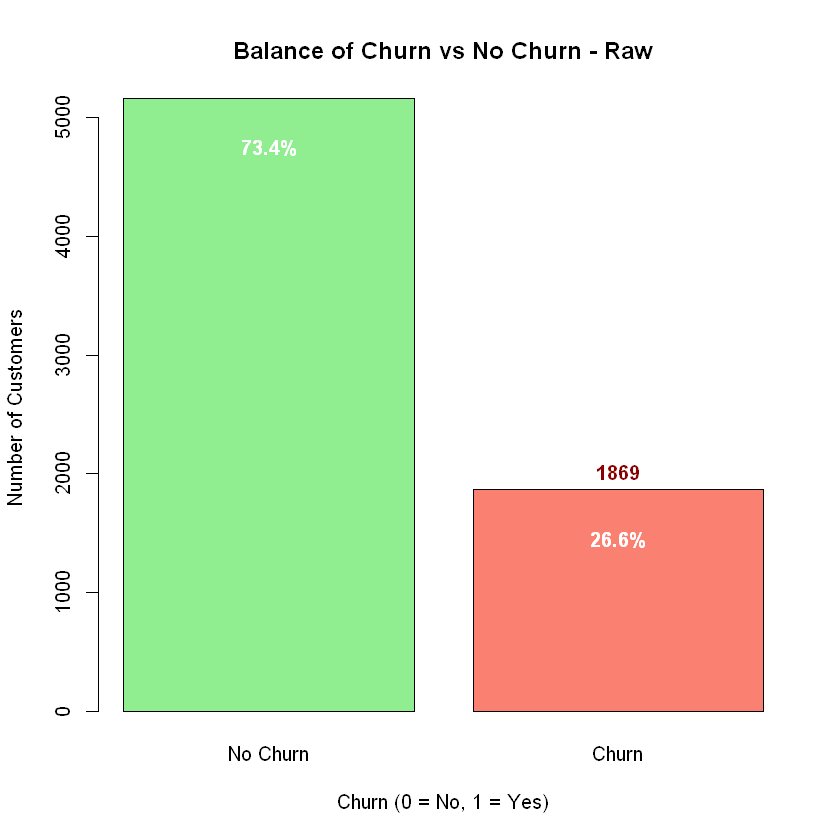

In [17]:
plot_churn_distribution(raw, "Churn", "Balance of Churn vs No Churn - Raw")

## 5.2 Categorical Variables

In [20]:
# Categorical Variables
frequencies <- lapply(raw[categorical_variables], function(x) {
  freq <- table(x)
  rel <- prop.table(freq)
  data.frame(
    category = names(freq),
    count = as.integer(freq),
    prop = as.numeric(rel),
    pct = as.numeric(rel*100)
  )
})

frequencies

category,count,prop,pct
<chr>,<int>,<dbl>,<dbl>
Female,3483,0.4953072,49.53072
Male,3549,0.5046928,50.46928
category,count,prop,pct
<chr>,<int>,<dbl>,<dbl>
No,5890,0.8375995,83.75995
Yes,1142,0.1624005,16.24005
category,count,prop,pct
<chr>,<int>,<dbl>,<dbl>
No,3639,0.5174915,51.74915


The exploratory study of the relationships between the various categorical explanatory variables and the response involves the individual analysis of the corresponding contingency tables.

In both situations (continuous or discrete explanatory variables), it must be taken into account that this analysis presented as graphs and tables **assess only the raw/crude relationship of the variable in question with the response**. In the regression model, the relationship to be evaluated will be the **adjusted relationship** for the remaining variables, which of course may be different from the first.

Only 2 variables has no significant crude relationship with the target variable: `gender` and `PhoneService`.

In [21]:
table(raw$Churn, raw$gender)
chisq.test(raw$Churn, raw$gender)

   
    Female Male
  0   2544 2619
  1    939  930


	Pearson's Chi-squared test with Yates' continuity correction

data:  raw$Churn and raw$gender
X-squared = 0.47545, df = 1, p-value = 0.4905


Some analysis we can do:

**SeniorCitizen**
The contingency table shows that roughly 16.2% of customers are senior citizens, while 83.8% are not. Among senior citizens, the churn rate is 476/(476+666) ≈ 41.7%, compared to only 1393/(1393+4497) ≈ 23.6% among non-seniors — a notable difference. This indicates that senior citizens are substantially more likely to churn than non-senior customers in this dataset.

The chi-squared test returns X² = 158.44, df = 1, p-value < 2.2e-16, which is highly significant. We therefore reject the null hypothesis of independence between `SeniorCitizen` and `Churn`, concluding that there is a strong statistically significant association between being a senior citizen and churning. This is consistent with the logistic regression result, where SeniorCitizen was one of the significant predictors (p = 0.0015).

**Dependents**
The contingency table shows that 70.2% of customers have no dependents and 29.8% do. Among customers without dependents, the churn rate is 1543/(1543+3390) ≈ 31.3%, compared to only 326/(326+1773) ≈ 15.5% among those with dependents — suggesting that having dependents is associated with lower churn.

The chi-squared test returns X² = 186.32, df = 1, p-value < 2.2e-16, also highly significant. We reject the null hypothesis of independence, concluding that there is a strong statistically significant association between having dependents and churning. Interestingly, despite this strong bivariate association, Dependents was not significant in the logistic regression (p ≈ 0.5157), which suggests its effect may be partially explained by other variables in the model such as tenure or Partner.

In [22]:
# Summary of chi-squared tests across categorical variables
chisq_summary <- do.call(rbind, lapply(categorical_variables, function(col) {
  test <- chisq.test(table(raw$Churn, raw[[col]]))
  data.frame(Variable = col, Chi2 = round(test$statistic, 2), 
             df = test$parameter, p_value = format.pval(test$p.value, digits = 3))
}))
chisq_summary[order(chisq_summary$Chi2, decreasing = TRUE), ]

,Variable,Chi2,df,p_value
,<chr>,<dbl>,<int>,<chr>
X-squared13,Contract,1179.55,2,<2e-16
X-squared7,OnlineSecurity,846.68,2,<2e-16
X-squared10,TechSupport,824.93,2,<2e-16
X-squared6,InternetService,728.70,2,<2e-16
X-squared15,PaymentMethod,645.43,3,<2e-16
X-squared8,OnlineBackup,599.18,2,<2e-16
X-squared9,DeviceProtection,555.88,2,<2e-16
X-squared12,StreamingMovies,374.27,2,<2e-16
X-squared11,StreamingTV,372.46,2,<2e-16


The barplots show that the categorical variables are not uniformly distributed across categories. For several variables, one or two categories clearly dominate (as for `SeniorCitizen` or `PhoneService`), which suggests that the customer base is concentrated in specific service and contract profiles. This is important for understanding the structure of the dataset and for identifying categories that may be associated with churn in later analysis. In addition, rare categories should be interpreted carefully, as they may contribute less reliable statistical patterns.

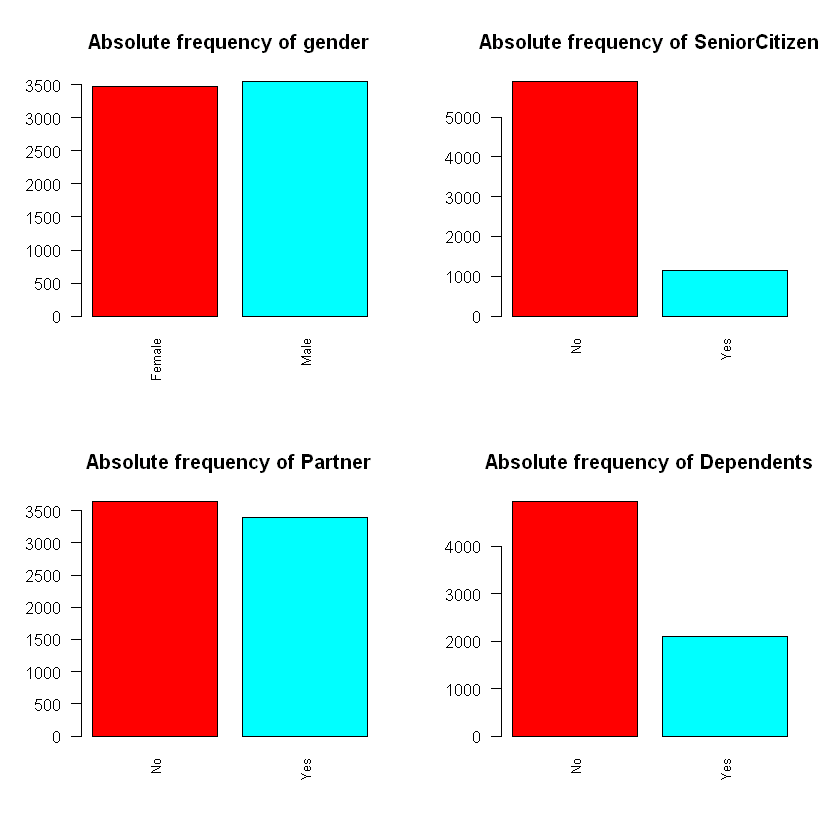

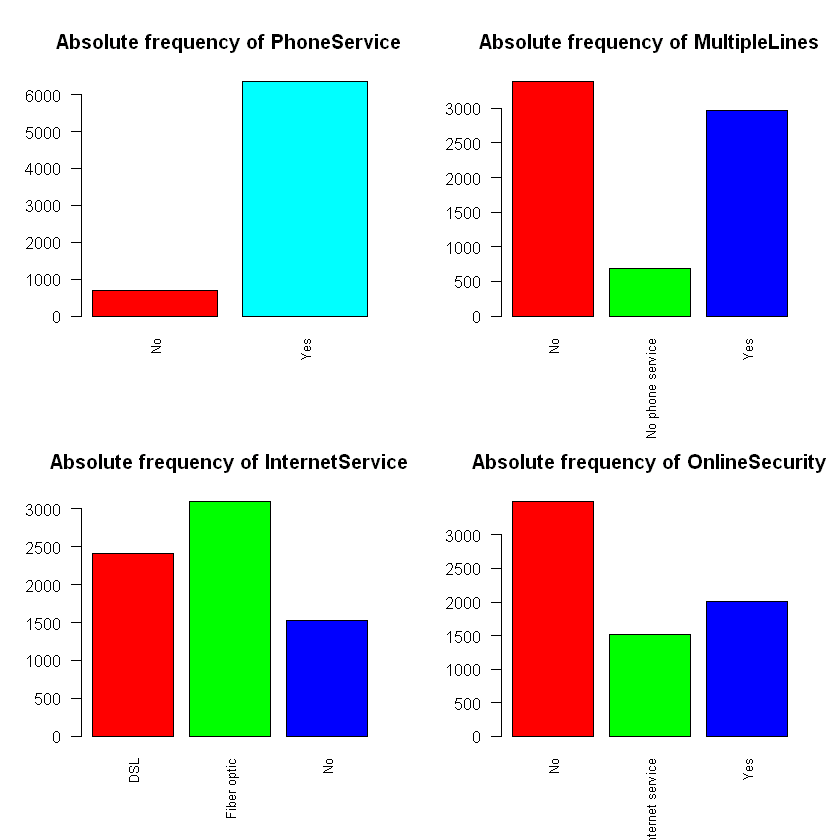

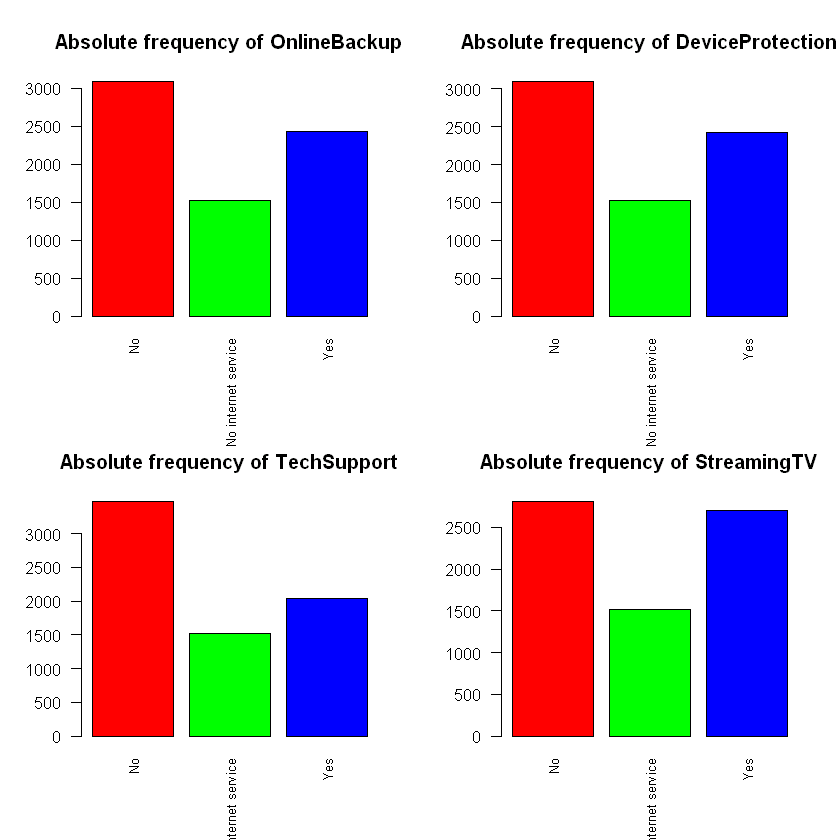

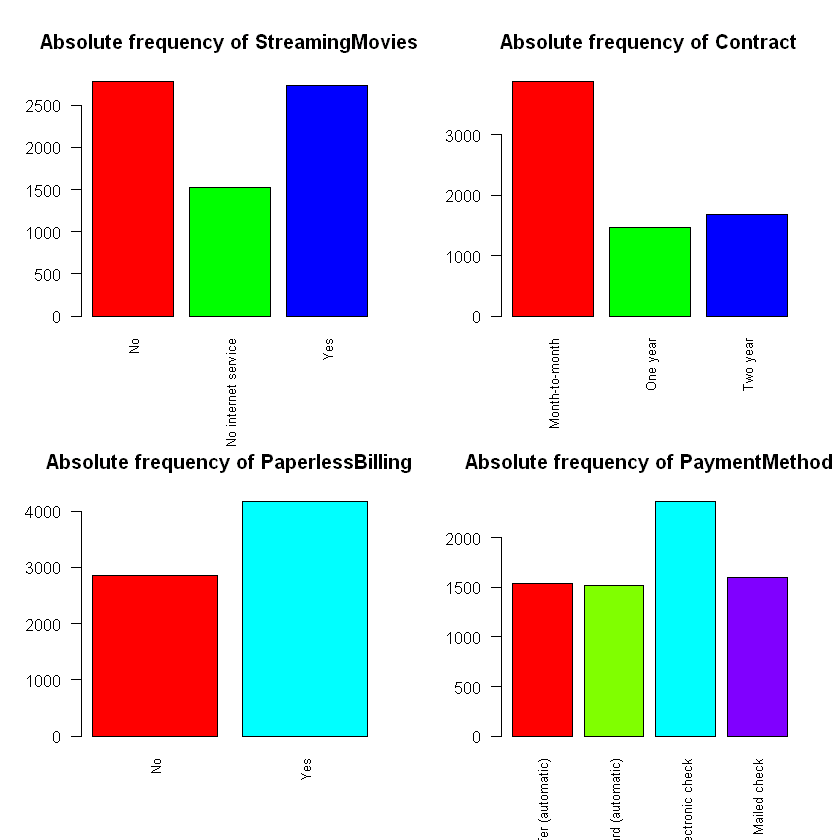

In [25]:
# Barplots for all categorical variables
par(mfrow = c(2, 2)) 
for (col in categorical_variables) {
  freq_table <- table(raw[[col]])
  barplot(freq_table,
          main = paste("Absolute frequency of", col),
          col = rainbow(length(freq_table)),
          las = 2,  
          cex.names = 0.8)  
}

# Reset para single plot
par(mfrow = c(1, 1))

## 5.3 Numerical/Continuous Variables

The density plots suggest that churn is more common among customers with higher `MonthlyCharges`. Customers with shorter `tenure` are also much more likely to churn. In addition, churners tend to have lower `TotalCharges`. However, this last result should be interpreted carefully, since TotalCharges is strongly related to tenure: newer customers have had less time to accumulate charges, and newer customers are also more likely to churn.

In [26]:
plot_continuous_by_churn <- function(data, vars, churn_col = "Churn") {
  
  plot_data <- data %>%
    select(all_of(c(churn_col, vars))) %>%
    pivot_longer(cols = all_of(vars), names_to = "Variable", values_to = "Value") %>%
    filter(!is.na(Value)) %>%
    mutate(
      ChurnGroup = case_when(
        .data[[churn_col]] %in% c("Yes", 1, "1") ~ "Churn",
        .data[[churn_col]] %in% c("No",  0, "0") ~ "Non-churn"
      ),
      ChurnGroup = factor(ChurnGroup, levels = c("Non-churn", "Churn"))
    )
  
  colours <- c("Non-churn" = "#4C78A8", "Churn" = "#E4572E")
  
  # Density plot (overlaid, as in original)
  p_density <- ggplot(plot_data, aes(x = Value, fill = ChurnGroup, colour = ChurnGroup)) +
    geom_density(alpha = 0.35, linewidth = 1.1) +
    facet_wrap(~ Variable, scales = "free") +
    scale_fill_manual(values = colours, name = "Customer status") +
    scale_colour_manual(values = colours, name = "Customer status") +
    labs(title = "Density by churn status", x = NULL, y = "Density") +
    theme_minimal() +
    theme(plot.title = element_text(face = "bold"), legend.position = "top")
  
  # Boxplot — churn groups side by side per variable
  p_box <- ggplot(plot_data, aes(x = ChurnGroup, y = Value, fill = ChurnGroup)) +
    geom_boxplot(alpha = 0.6, outlier.size = 0.8, outlier.alpha = 0.4, width = 0.5) +
    facet_wrap(~ Variable, scales = "free_y") +
    scale_fill_manual(values = colours, name = "Customer status") +
    labs(title = "Boxplot by churn status", x = NULL, y = "Value") +
    theme_minimal() +
    theme(
      plot.title  = element_text(face = "bold"),
      legend.position = "none",
      axis.text.x = element_text(size = 10)
    )
  
  print(p_density)
  print(p_box)
}

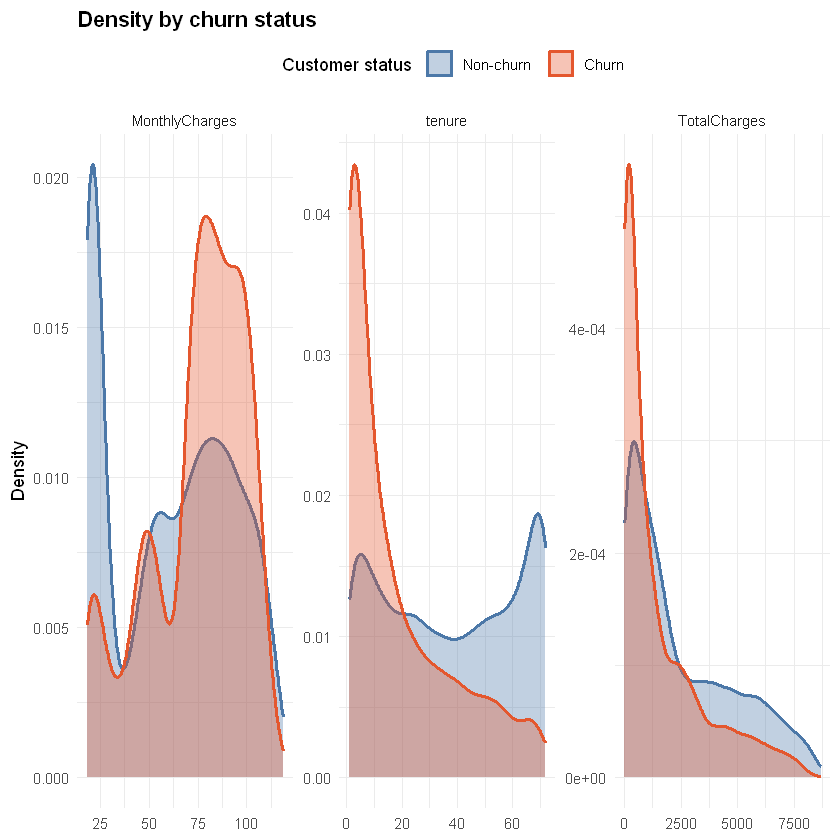

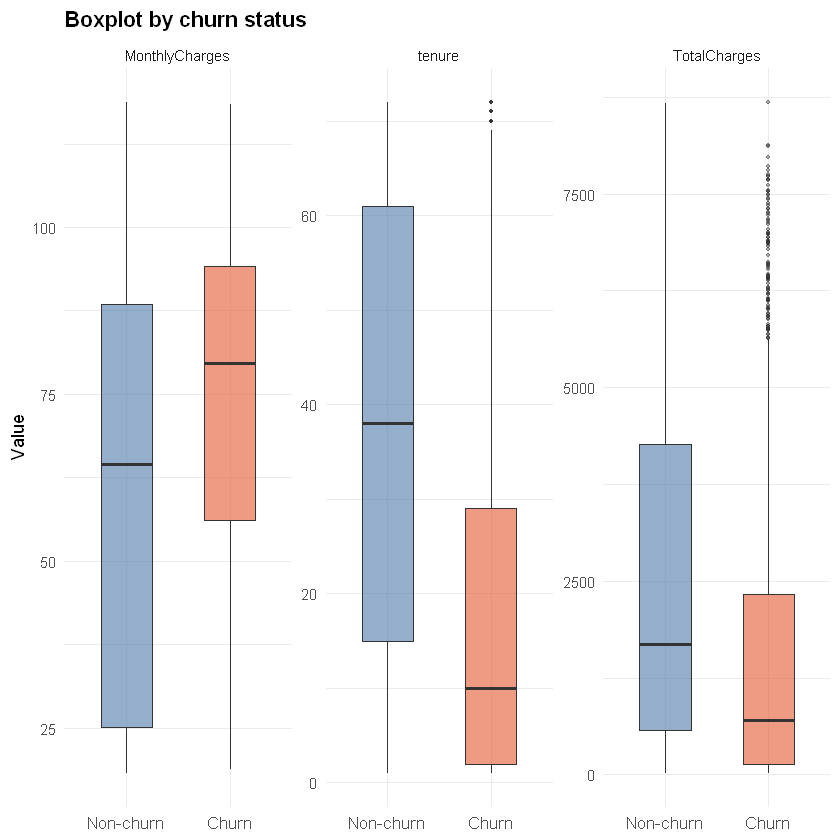

In [78]:
plot_continuous_by_churn(
    raw, 
    vars = c("tenure", "MonthlyCharges", "TotalCharges")
    )

In [55]:
detach(raw)

# 6. Feature Engineering

### 6.1 Numerical Variables: No Scaling Required

Standardisation is not required for logistic regression estimated via maximum likelihood, as `glm()` with family = "binomial" is scale-invariant — no penalty term, no distance computation, no gradient descent over raw inputs. The coefficients will be estimated correctly regardless of whether tenure is in months (1–72) or z-scores (−1.5 to 1.8). The model doesn't care. Therefore, interpretability is more important here. Odds ratios on the original scale have a natural business meaning — "each additional month of tenure reduces the odds of churn by X%" is something a stakeholder understands. So, **we won't standardize numerical variables in the current approach**. We **retain the original units of `tenure`, `MonthlyCharges`, and `TotalCharges` to preserve the direct interpretability** of the odds ratios in business terms.

In case we intend to standardize numerical variables to input these data into a different model, we should do this after splitting the data into train and test. The reason is that if we scale the entire dataset, the mean and SD used are calculated using the 7032 rows, including the test set. The test set has quietly influenced how the training data was transformed. This is called data leakage — information from the future (or from held-out data) sneaking into the training process. Therefore, we should calculate the mean and SD only from the training set, then apply those same numbers to scale the test set. The test set gets scaled, but using parameters it had no part in creating.
 

### 6.2 Categorical Variables: Collapsing Redundant Levels

In [27]:
# Checking if the categories have spaces or errors
unique_categories <- lapply(raw[categorical_variables], function(x) sort(unique(na.omit(x))))
unique_categories

$gender
[1] "Female" "Male"  

$SeniorCitizen
[1] No  Yes
Levels: No Yes

$Partner
[1] "No"  "Yes"

$Dependents
[1] "No"  "Yes"

$PhoneService
[1] "No"  "Yes"

$MultipleLines
[1] "No"               "No phone service" "Yes"             

$InternetService
[1] "DSL"         "Fiber optic" "No"         

$OnlineSecurity
[1] "No"                  "No internet service" "Yes"                

$OnlineBackup
[1] "No"                  "No internet service" "Yes"                

$DeviceProtection
[1] "No"                  "No internet service" "Yes"                

$TechSupport
[1] "No"                  "No internet service" "Yes"                

$StreamingTV
[1] "No"                  "No internet service" "Yes"                

$StreamingMovies
[1] "No"                  "No internet service" "Yes"                

$Contract
[1] "Month-to-month" "One year"       "Two year"      

$PaperlessBilling
[1] "No"  "Yes"

$PaymentMethod
[1] "Bank transfer (automatic)" "Credit card (automatic)"  
[3] "Electronic check"          "Mailed check"

Based on the above categories, we can easily see some are highly related as those defined as "No internet service". Let's confirm this.

We can recode the redundant categories into the existing "No" category. This makes logical sense - a customer with "No internet service" effectively has "No" `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`. Similarly, a customer with "No phone service" has "No" `MultipleLines`.

In [28]:
all((raw$MultipleLines == "No phone service") == (raw$PhoneService == "No"))
all((raw$OnlineSecurity == "No internet service") == (raw$InternetService == "No"))
all((raw$OnlineBackup == "No internet service") == (raw$InternetService == "No"))
all((raw$DeviceProtection == "No internet service") == (raw$InternetService == "No"))
all((raw$TechSupport == "No internet service") == (raw$InternetService == "No"))
all((raw$StreamingTV == "No internet service") == (raw$InternetService == "No"))
all((raw$StreamingMovies == "No internet service") == (raw$InternetService == "No"))

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

Collapsing these redundant categories simplifies the model: instead of the model learning separate coefficients for "No" and "No internet service" — which are identical states — it now has a single "No" reference level. This reduces dummy variable proliferation and avoids aliasing issues in the design matrix.

In [29]:
# Fix MultipleLines
raw$MultipleLines <- ifelse(raw$MultipleLines == "No phone service", "No", raw$MultipleLines)

# Fix all internet-dependent variables
internet_vars <- c("OnlineSecurity", "OnlineBackup", "DeviceProtection", 
                   "TechSupport", "StreamingTV", "StreamingMovies")

for (var in internet_vars) {
  raw[[var]] <- ifelse(raw[[var]] == "No internet service", "No", raw[[var]])
}

In [30]:
lapply(raw[categorical_variables], function(x) sort(unique(na.omit(x))))

$gender
[1] "Female" "Male"  

$SeniorCitizen
[1] No  Yes
Levels: No Yes

$Partner
[1] "No"  "Yes"

$Dependents
[1] "No"  "Yes"

$PhoneService
[1] "No"  "Yes"

$MultipleLines
[1] "No"  "Yes"

$InternetService
[1] "DSL"         "Fiber optic" "No"         

$OnlineSecurity
[1] "No"  "Yes"

$OnlineBackup
[1] "No"  "Yes"

$DeviceProtection
[1] "No"  "Yes"

$TechSupport
[1] "No"  "Yes"

$StreamingTV
[1] "No"  "Yes"

$StreamingMovies
[1] "No"  "Yes"

$Contract
[1] "Month-to-month" "One year"       "Two year"      

$PaperlessBilling
[1] "No"  "Yes"

$PaymentMethod
[1] "Bank transfer (automatic)" "Credit card (automatic)"  
[3] "Electronic check"          "Mailed check"

# 7. Training and model fitting

As said above, churned customers form the minority class, while retained customers form the majority class. 

Though this imbalance reflects good business health, it can pose a real challenge for machine learning algorithms trying to learn an effective predictive model. 

`createDataPartition()` performs stratified random sampling, preserving the ~26.5% churn rate in both training and test sets. This is important: naive random splitting on imbalanced data can create sets with quite different class proportions, leading to unstable evaluation metrics.

In [31]:
set.seed(111)
Training <- createDataPartition(raw$Churn, p = 0.7, list = FALSE)
training <- raw[Training, ] # 4924 21
testing <- raw[-Training, ] # 2108 21

dim(training)
dim(testing)

[1] 4924   21

[1] 2108   21

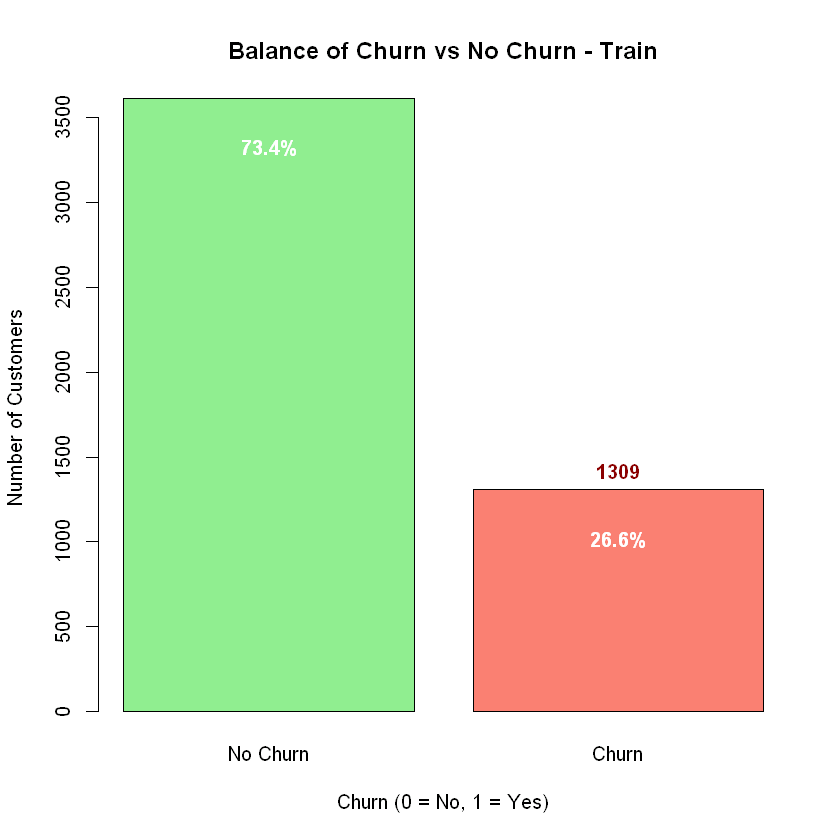

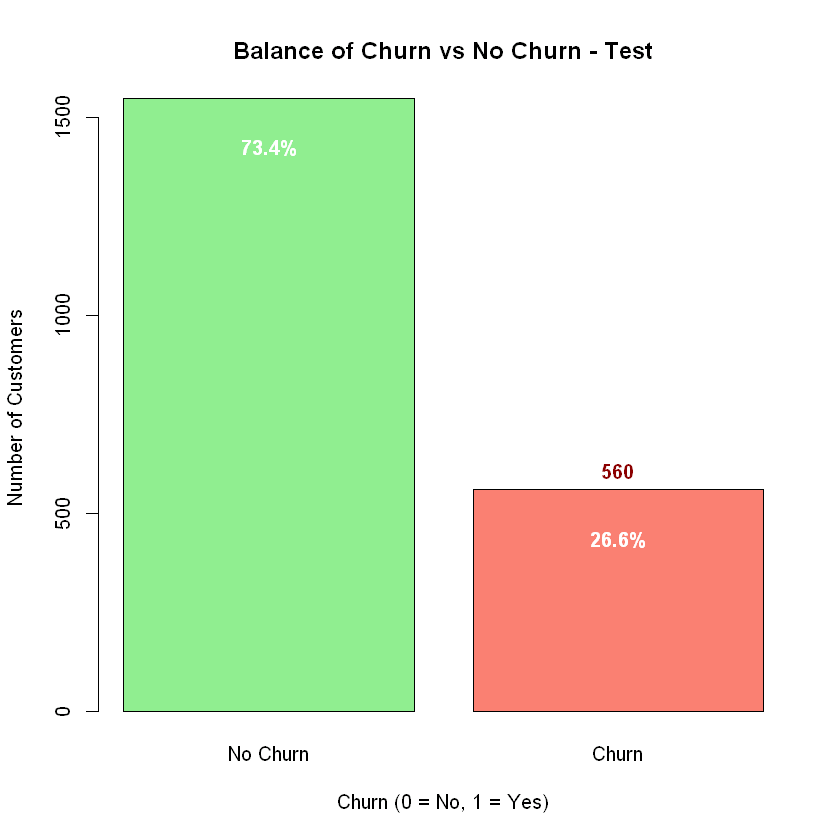

In [32]:
plot_churn_distribution(training, "Churn", "Balance of Churn vs No Churn - Train")
plot_churn_distribution(testing, "Churn", "Balance of Churn vs No Churn - Test")

#### Standardizing numerical variables in training and testing - in case we intend to test another model.

If scaling were needed (e.g. for a penalised model), it must be fit on training data only and applied to test — see caret::preProcess()." 

In [ ]:
# Step 1: Learn the mean and SD from the training set only: this just calculates and stores the mean and SD of tenure, MonthlyCharges, and TotalCharges in the training data.
# preproc <- preProcess(training[, numerical_variables], method = c("center", "scale"))

# # Step 2: Apply those stored parameters to scale the training set
# training[, numerical_variables] <- predict(preproc, training[, numerical_variables])

# # Step 3: Apply those SAME stored parameters to scale the test set
# testing[, numerical_variables] <- predict(preproc, testing[, numerical_variables])

#### Multicollinearity

The phenomenon of multicollinearity corresponds to the existence of linear associations between the explanatory variables. High multicollinearity indicates that there is redundancy in the information provided by the explanatory variables. There are several ways to analyse the possible existence of multicollinearity. One of them is through the correlation matrix between the explanatory variables. In a situation where two variables have a very high correlation, that is, very close to 1 (usually correlations greater than 0.75), this is said to indicate a multicollinearity problem. When this occurs, we should consider to remove one of the variable from the model, keeping those that make the most sense in the context of the problem, and this new model should then be re-estimated so that its quality can be reassessed.

The matrix suggests the existence of multicollinearity between the variable `TotalCharges` and the variable `tenure`, whose correlation coefficient is equal to 0.83. For a clearer view of this possible high correlation, the graph for the highest values of 𝑅² was also created.


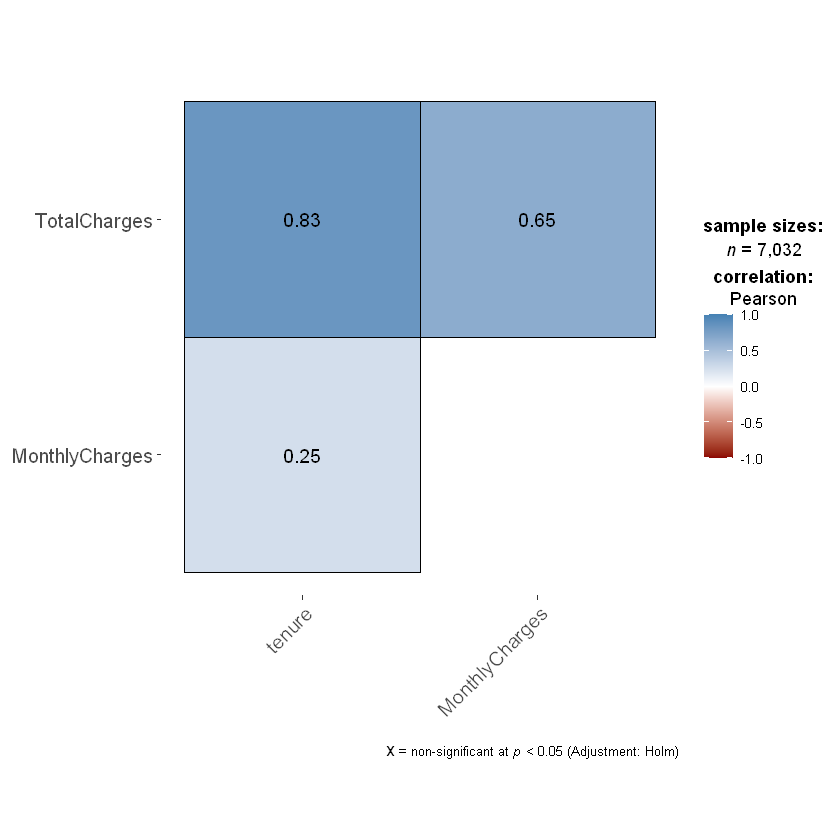

In [33]:
ggcorrmat(data = raw,
          type = "parametric", # parametric for Pearson, nonparametric for Spearman's correlation
          colors = c("darkred", "white", "steelblue")) # change default colors


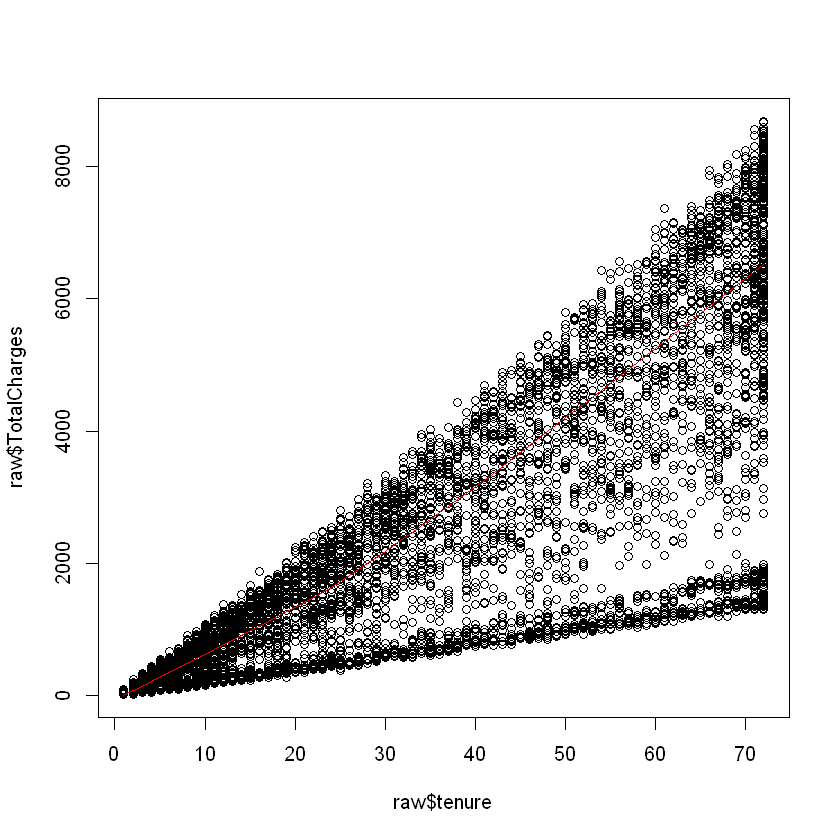

In [34]:
par(mfrow=c(1,1))
plot(raw$tenure, raw$TotalCharges)
lines(lowess(raw$tenure, raw$TotalCharges), col="red")

We start with the full model (all 19 predictors) as our baseline. This serves two purposes: 
1. it establishes an upper bound on model complexity, and 
2. it allows us to identify non-significant predictors through the summary output, which will guide stepwise refinement in the next stage.

The algorithm, by default, models the response Y=1. 

This function also created the dummies for each categorical variable, selecting for each variable, the first class as the reference class. If we want to set other classes as the reference ones, we need to change the order of the categories before running `glm` or do the following: `base <- within(base, var <- relevel(var, ref = 3))` to make the 3rd var the ref. 

In the summary output: the `residual deviance` is the deviance for the model as it is, while `null deviance` is the deviance for the null model (the model that only contains the constant).

**1. Training:** Fitting the initial logistic regression model (`model1`)

In [35]:
model1 <- glm(
  Churn ~ tenure + MonthlyCharges + TotalCharges + gender + SeniorCitizen + Partner + Dependents + PhoneService + 
  MultipleLines + InternetService + OnlineSecurity + OnlineBackup + DeviceProtection + TechSupport + StreamingTV + 
  StreamingMovies + Contract + PaperlessBilling + PaymentMethod,
  family = "binomial",
  data = training
)

summary(model1)


Call:
glm(formula = Churn ~ tenure + MonthlyCharges + TotalCharges + 
    gender + SeniorCitizen + Partner + Dependents + PhoneService + 
    MultipleLines + InternetService + OnlineSecurity + OnlineBackup + 
    DeviceProtection + TechSupport + StreamingTV + StreamingMovies + 
    Contract + PaperlessBilling + PaymentMethod, family = "binomial", 
    data = training)

Coefficients:
                                       Estimate Std. Error z value Pr(>|z|)    
(Intercept)                           1.251e+00  9.746e-01   1.283 0.199360    
tenure                               -6.190e-02  7.592e-03  -8.154 3.52e-16 ***
MonthlyCharges                       -4.485e-02  3.794e-02  -1.182 0.237268    
TotalCharges                          3.493e-04  8.504e-05   4.107 4.00e-05 ***
genderMale                           -8.867e-02  7.754e-02  -1.144 0.252798    
SeniorCitizenYes                      3.219e-01  1.016e-01   3.168 0.001536 ** 
PartnerYes                           -4.679e-02  9.27

**Deviance test vs Hosmer-Lemeshow**

The deviance goodness-of-fit test works well when **multiple observations share the same combination of predictor values**. With enough observations per group, the test has reliable statistical properties.

The problem in this dataset is that we have three continuous variables (tenure, MonthlyCharges, TotalCharges). Once continuous variables are in the model, virtually every row has a unique combination of predictor values. There are no groups to aggregate within — each "group" has exactly one observation. 

In that situation the deviance test breaks down and the p-value becomes unreliable, typically coming out close to 1 almost regardless of actual fit.

The **Hosmer-Lemeshow test** sidesteps this by ignoring the original covariate combinations entirely. The fundamental test of the Hosmer-Lemeshow statistic is the null hypothesis that the model fits the data, and the alternative is the model does not fit the data. The
statistic for this test is given by examining the differences between the observed and expected frequencies within the deciles

* A non-significant p-value (above 0.05) means observed and expected counts agree across the probability range — the model fits adequately. 
* A significant result flags systematic misfitting in some probability range, e.g. the model overestimates churn probability for low-risk customers.

In our case p=0.036, therefore, the null hypothesis that the observed and expected proportions are the same across all doses **is rejected.**. With n ≈ 4,900, the HL test is sensitive to trivial deviations. The marginal p-value (0.036) should be interpreted cautiously — the calibration plots and AUC are more informative at this sample size.

In [39]:
# install.packages("ResourceSelection")

In [ ]:
hoslem.test(as.numeric(as.character(training$Churn)), fitted(model1), g = 10)

Warning message:
"package 'ResourceSelection' was built under R version 4.4.3"
ResourceSelection 0.3-6 	 2023-06-27




	Hosmer and Lemeshow goodness of fit (GOF) test

data:  as.numeric(as.character(training$Churn)), fitted(model1)
X-squared = 16.476, df = 8, p-value = 0.03605


**Checking for potential interactions using `add1()`.**

We use `add1()` to screen all pairwise interactions for statistical significance (via the likelihood-ratio chi-squared test). Any interaction with a p-value below 0.05 merits further investigation. In practice, we would only add an interaction if it is both statistically significant *and* substantively interpretable in business terms — avoiding overfitting from spurious associations.

In [40]:
add1_results <- add1(model1, . ~ .^2, test = "Chisq")
print(as.data.frame(add1_results), row.names = TRUE)

                                  Df Deviance      AIC          LRT
<none>                            NA 4070.811 4118.811           NA
tenure:MonthlyCharges              1 4070.550 4120.550 2.604184e-01
tenure:TotalCharges                1 4056.809 4106.809 1.400200e+01
tenure:gender                      1 4058.885 4108.885 1.192602e+01
tenure:SeniorCitizen               1 4068.372 4118.372 2.438552e+00
tenure:Partner                     1 4069.438 4119.438 1.372348e+00
tenure:Dependents                  1 4070.185 4120.185 6.260015e-01
tenure:PhoneService                1 4067.530 4117.530 3.280779e+00
tenure:MultipleLines               1 4069.142 4119.142 1.668536e+00
tenure:InternetService             2 4063.644 4115.644 7.167036e+00
tenure:OnlineSecurity              1 4069.733 4119.733 1.077641e+00
tenure:OnlineBackup                1 4066.047 4116.047 4.763610e+00
tenure:DeviceProtection            1 4070.597 4120.597 2.136454e-01
tenure:TechSupport                 1 4069.848 41

**Model Diagnostics**

* **Cook's Distance**: identifies highly influential observations that may be distorting coefficient estimates (overall influence of each observation on the coefficient estimates)
* **Leverage plot**: flags observations with unusual predictor combinations (unusual predictor combinations combined with poor fit)

No extreme outliers or leverage points are evident, suggesting the model estimates are stable.

No observations exceed a Cook's Distance threshold of 4/n ≈ 0.0008 by a concerning margin, and the leverage plot shows no points in the high-
influence region. The coefficient estimates appear stable.

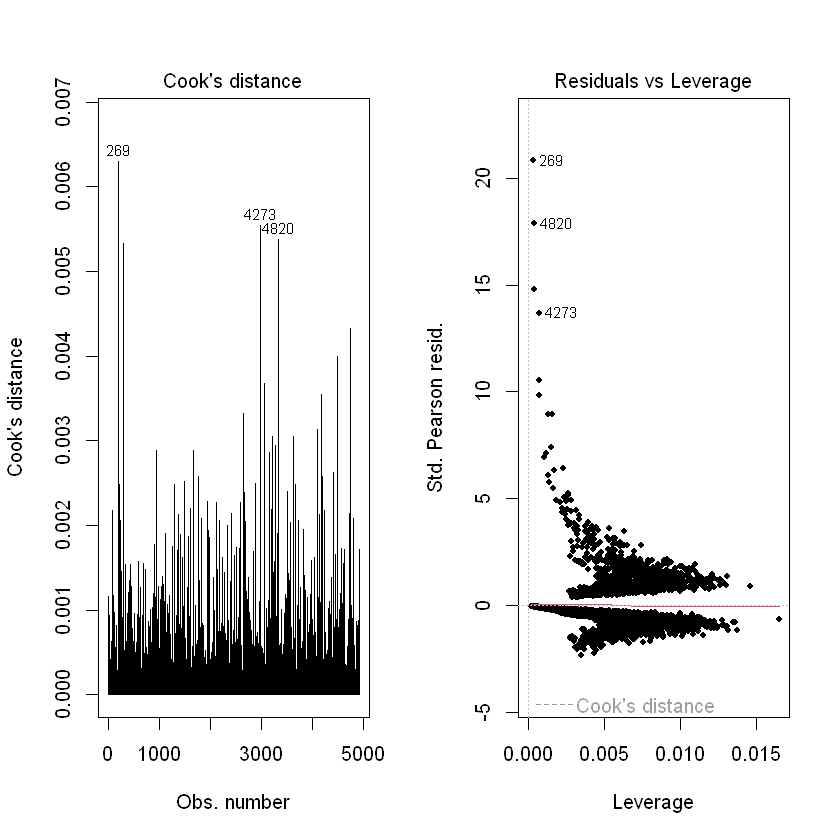

In [41]:
par(mfrow=c(1,2))
plot(model1, which=4, pch=20) # Cook's Distance
plot(model1, which=5, pch=20) # Leverage vs Residuals Squared

# 8. Testing and Evaluation

**Test-Set Evaluation**: Evaluate the model's performance on the unseen test data, including confusion matrix, ROC curve, and AUC to measure predictive accuracy and discriminatory power.

We use a classification threshold of 0.5 as a starting point. In a churn context, this may not be optimal: the cost of a false negative (missing a churner) is typically higher than the cost of a false positive (flagging a loyal customer for a retention offer). In a production setting, the threshold would be tuned to minimise expected business cost rather than maximise accuracy.

In [ ]:
prob_test <- predict(model1, newdata = testing, type = "response")

# we can see the probabilities of churn for each customer in the test set
results <- data.frame(
  customerID = testing$customerID,
  churn_probability = prob_test
)

head(results)

,customerID,churn_probability
,<chr>,<dbl>
2,5575-GNVDE,0.03467962
7,1452-KIOVK,0.52423753
12,7469-LKBCI,0.02602467
13,8091-TTVAX,0.17153059
15,5129-JLPIS,0.42781477
16,3655-SNQYZ,0.03977448


We turn the predicted probabilities into binary predictions using a 0.5 threshold. We can adjust the threshold if we want to be more or less conservative in predicting churn. See below. By doing this transformation, we move from “how likely is churn?” to “predict churn or not?”

In [ ]:
pred_test <- ifelse(prob_test >= 0.5, 1, 0) 
pred_test <- factor(pred_test, levels = c(0, 1))
obs_test <- factor(testing$Churn, levels = c(0, 1))

cm <- confusionMatrix(pred_test, obs_test, positive = "1")
cm

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1379  241
         1  169  319
                                          
               Accuracy : 0.8055          
                 95% CI : (0.7879, 0.8222)
    No Information Rate : 0.7343          
    P-Value [Acc > NIR] : 1.338e-14       
                                          
                  Kappa : 0.4802          
                                          
 Mcnemar's Test P-Value : 0.0004541       
                                          
            Sensitivity : 0.5696          
            Specificity : 0.8908          
         Pos Pred Value : 0.6537          
         Neg Pred Value : 0.8512          
             Prevalence : 0.2657          
         Detection Rate : 0.1513          
   Detection Prevalence : 0.2315          
      Balanced Accuracy : 0.7302          
                                          
       'Positive' Class : 1               
                        

In [43]:
Precision <- cm$byClass["Pos Pred Value"]
Recall <- cm$byClass["Sensitivity"]
F1_Score <- 2 * (Precision * Recall) / (Precision + Recall) 
data.frame(
  Precision = Precision,
  Recall = Recall,
  F1_Score = F1_Score
)

,Precision,Recall,F1_Score
,<dbl>,<dbl>,<dbl>
Pos Pred Value,0.6536885,0.5696429,0.6087786


The ROC AUC score measures the area under the Receiver Operating Characteristic (ROC) curve. The ROC curve plots the true positive rate against the false positive rate at different probability thresholds used to classify observations into the positive or negative class.

By measuring the area addressed under this curve, we can evaluate the model’s ability to distinguish between churners and non-churners across all possible threshold values. The AUC obtained for the current model, close to 0.85, indicates good discriminatory performance. In other words, the model is generally effective at ranking positive cases higher than negative ones. However, there is still room for improvement, since a perfect classifier would achieve an AUC of 1.00.

Visualizing the curve (and the area under it) makes the concept of area under the curve (AUC) a little easier to understand.

An AUC of ~0.85 means that if we randomly pick one churner and one non-churner, the model assigns a higher churn probability to the churner 85% of the time — a meaningful discrimination capability.


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.8464

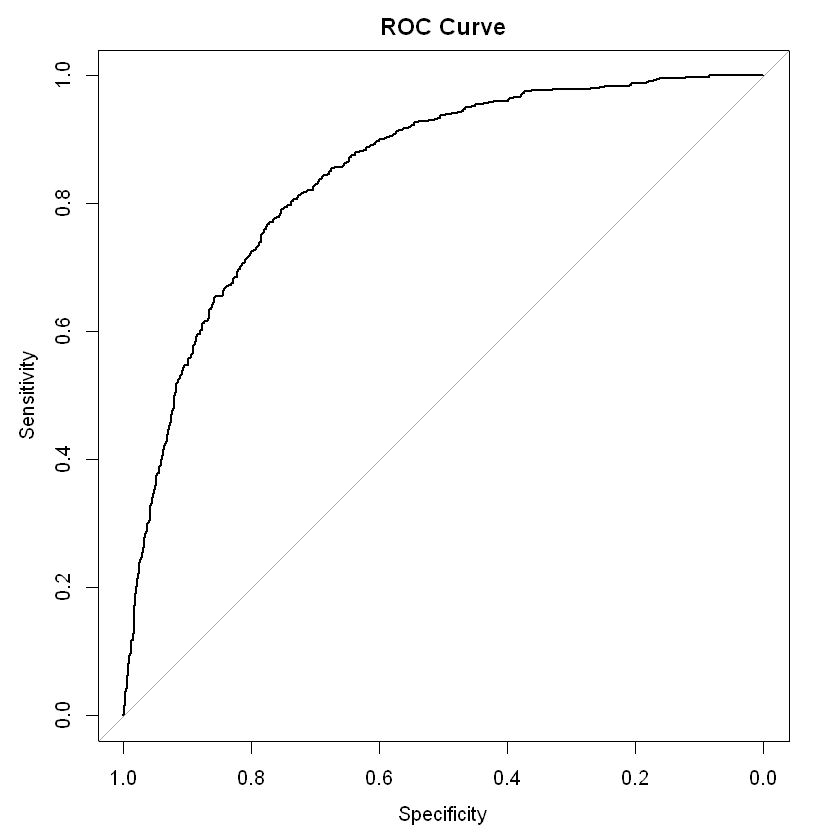

In [71]:
roc_curve <- roc(testing$Churn, prob_test)
plot(roc_curve, main = "ROC Curve")
auc(roc_curve)

**Finding a better threshold** we can find the optimal threshold empirically using our ROC curve — Maximising the F1 score (balances precision and recall, good default for imbalanced problems)

In [ ]:
roc_obj   <- roc(testing$Churn, prob_test)
thresholds <- coords(roc_obj, "all", ret = c("threshold", "sensitivity", "specificity",
                                              "ppv", "npv"), transpose = FALSE)

thresholds$f1 <- with(thresholds, 
                       2 * (ppv * sensitivity) / (ppv + sensitivity))

best_f1 <- thresholds[which.max(thresholds$f1), ]
best_f1

Setting levels: control = 0, case = 1

Setting direction: controls < cases



,threshold,sensitivity,specificity,ppv,npv,f1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1326,0.3167177,0.7714286,0.7732558,0.5517241,0.9033962,0.6433358


In [70]:
optimal_threshold <- best_f1$threshold   

pred_test_optimal <- ifelse(prob_test >= optimal_threshold, 1, 0)
pred_test_optimal <- factor(pred_test_optimal, levels = c(0, 1))

cm_optimal <- confusionMatrix(pred_test_optimal, obs_test, positive = "1")
cm_optimal

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1197  128
         1  351  432
                                          
               Accuracy : 0.7728          
                 95% CI : (0.7543, 0.7905)
    No Information Rate : 0.7343          
    P-Value [Acc > NIR] : 2.772e-05       
                                          
                  Kappa : 0.4833          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.7714          
            Specificity : 0.7733          
         Pos Pred Value : 0.5517          
         Neg Pred Value : 0.9034          
             Prevalence : 0.2657          
         Detection Rate : 0.2049          
   Detection Prevalence : 0.3714          
      Balanced Accuracy : 0.7723          
                                          
       'Positive' Class : 1               
                        

* **Recall went up:** 0.570 → 0.771 — the model now catches 77% of actual churners instead of 57%. That's a significant improvement in the metric that matters most in churn.
* **Precision went down:** 0.654 → 0.552 — of the customers flagged as churners, fewer are actually churners. More false alarms.
* **F1 improved:** 0.609 → 0.643 — the overall balance between precision and recall is better.
* **Specificity dropped:** 0.891 → 0.773 — more non-churners are being incorrectly flagged.

The question is: what happens to a flagged customer? Almost certainly they receive a **retention offer** — a discount, a free month, an upgrade. That has a cost, but it's a known and relatively small cost.

A **missed churner** (false negative) is a customer who leaves. That means losing their entire future revenue stream — months or years of monthly charges. That cost is much larger.
With that framing, the 0.317 threshold is the better operating point for this problem. We're trading some precision (more unnecessary retention offers sent) for substantially higher recall (far fewer churners slipping through undetected). In most telco contexts that is the right trade-off.



In [47]:
# Comparing default vs optimised threshold
data.frame(
  Threshold  = c(0.50, round(optimal_threshold, 3)),
  Precision  = c(cm$byClass["Pos Pred Value"],  cm_optimal$byClass["Pos Pred Value"]),
  Recall     = c(cm$byClass["Sensitivity"],      cm_optimal$byClass["Sensitivity"]),
  F1         = c(cm$byClass["F1"],               cm_optimal$byClass["F1"]),
  Specificity = c(cm$byClass["Specificity"],     cm_optimal$byClass["Specificity"])
)

Threshold,Precision,Recall,F1,Specificity
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.500,0.6536885,0.5696429,0.6087786,0.8908269
0.317,0.5517241,0.7714286,0.6433358,0.7732558


**Odds Ratios and Interpretations**: Compute and visualize odds ratios to interpret the impact of predictors on churn probability.

Let's check our coefficients. The coefficients table contains information about the estimated coefficients for the regression equation. Note that exp(B) corresponds to the odds ratio for the response exposure (Y = 1) whenever we increase the corresponding covariate by one unit, keeping the remaining explanatory variables constant.

We then have (just some interpretations):

* 0.940 represents the odds ratio for churn (versus non-churn) for each additional unit of tenure. Every extra period of tenure decreases the odds of churn by approximately 6%, suggesting that tenure is a protective factor — longer-standing customers are less likely to churn.

* 0.915 represents the odds ratio for churn (versus non-churn) for male customers, as opposed to female customers. Male customers have odds of churn approximately 8.5% lower than female customers, though the effect is modest (and not significant if we analyse the summery above).
...

* 1.410 represents the odds ratio for churn (versus non-churn) for PaperlessBillingYes. While 0.709 represents the odds ratio for churn for PaperlessBillingNo. This means that not having paperless billing decreases the odds of churn by approximately 29.1%, acting as a protective factor against churn.

In [48]:
odds_ratios <- exp(coef(model1))
odds_ratios

(Intercept)                               tenure 
                           3.4930931                            0.9399751 
                      MonthlyCharges                         TotalCharges 
                           0.9561457                            1.0003494 
                          genderMale                     SeniorCitizenYes 
                           0.9151457                            1.3797960 
                          PartnerYes                        DependentsYes 
                           0.9542885                            0.9325855 
                     PhoneServiceYes                     MultipleLinesYes 
                           1.3197077                            1.6449311 
          InternetServiceFiber optic                    InternetServiceNo 
                           6.6417395                            0.1552361 
                   OnlineSecurityYes                      OnlineBackupYes 
                           0.8104880                            1.0141895 
                 DeviceProtectionYes                       TechSupportYes 
                           1.1395192                            0.8848424 
                      StreamingTVYes                   StreamingMoviesYes 
                           1.9235985                            1.8442537 
                    ContractOne year                     ContractTwo year 
                           0.5218403                            0.2290161 
                 PaperlessBillingYes PaymentMethodCredit card (automatic) 
                           1.4099425                            1.0009968 
       PaymentMethodElectronic check            PaymentMethodMailed check 
                           1.3618284                            0.9633495

Waiting for profiling to be done...

Waiting for profiling to be done...



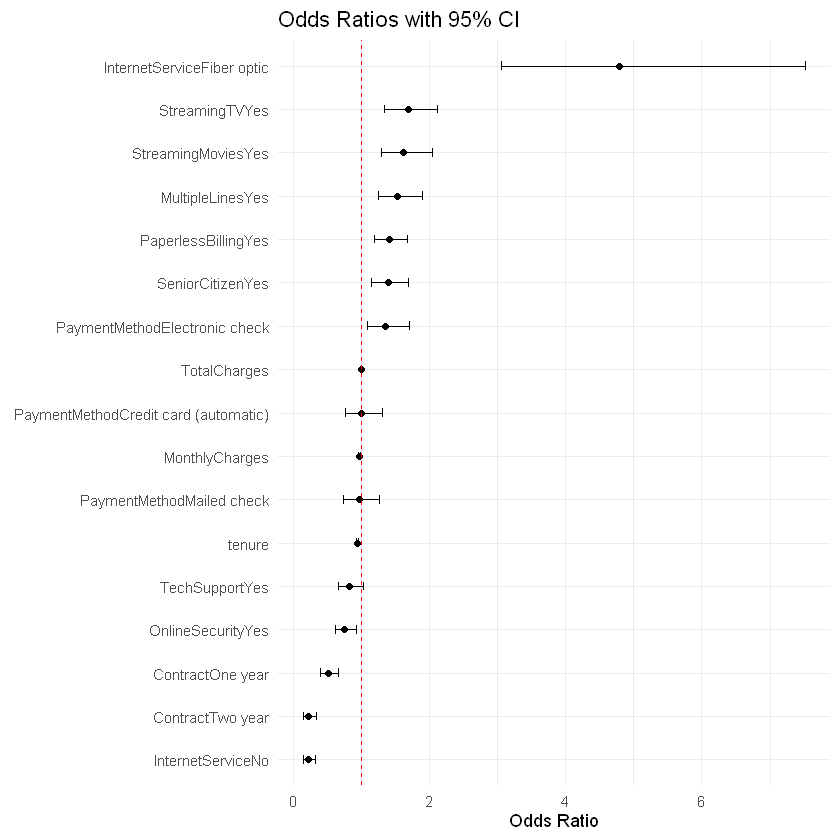

In [ ]:
or_df <- data.frame(
  term = names(coef(final_model))[-1],
  OR   = exp(coef(final_model))[-1],
  lower = exp(confint(final_model))[-1, 1],
  upper = exp(confint(final_model))[-1, 2]
)
ggplot(or_df, aes(x = reorder(term, OR), y = OR)) +
  geom_point() + geom_errorbar(aes(ymin=lower, ymax=upper), width=0.2) +
  geom_hline(yintercept=1, linetype="dashed", colour="red") +
  coord_flip() + labs(title="Odds Ratios with 95% CI", x=NULL, y="Odds Ratio") +
  theme_minimal()

95% confidence intervals for the log-odds coefficients — none span zero for key predictors (tenure, Contract, InternetService)

In [72]:
confint(model1)

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),-0.658837336,3.1627198390
tenure,-0.077077102,-0.0473097438
MonthlyCharges,-0.119306354,0.0294819688
TotalCharges,0.000184724,0.0005182008
genderMale,-0.240731752,0.0632783823
SeniorCitizenYes,0.122714927,0.5212079691
PartnerYes,-0.228646131,0.1351789989
DependentsYes,-0.280913467,0.1402125713
PhoneServiceYes,-1.239939392,1.7962457515
MultipleLinesYes,0.081909746,0.9145496408


# 9. Refinement
Based on diagnostics and performance, consider simplifying the model (e.g., removing non-significant variables), addressing multicollinearity, or exploring interactions further.

#### Options A: Based on individuals analysis above, some possible options for removals:

**Removing First (clearly non-significant, no meaningful interactions)** \
`OnlineBackup` — p = 0.946**, the highest p-value in the model, and no significant interactions with any other variable. Safe to remove immediately.
`PaymentMethodCredit card` / `PaymentMethodMailed check` — within PaymentMethod, only Electronic check is significant (p = 0.007). However, since PaymentMethod is a single categorical variable, we cannot remove individual levels — so keep it for now and reassess after other removals. 

**Removing Second** \
`DeviceProtection` (p = 0.539) and `TechSupport` (p = 0.573) — both clearly non-significant and no relevant interactions worth preserving.
`OnlineSecurity` (p = 0.323) — non-significant, and its interactions with other variables are all above 0.05.

**Removing Third** \
`Partner` (p = 0.614) and `Dependents` (p = 0.516) — both non-significant. Note that `Dependents:PhoneService` has p = 0.013, but given that `PhoneService` itself is non-significant (p = 0.720), this interaction is not worth retaining. \
`gender` (p = 0.253) — non-significant, though `gender:MultipleLines` shows p = 0.032. Worth checking if this interaction remains relevant after other removals.

**Handle With Care** \
`PhoneService` (p = 0.720) — clearly non-significant on its own, but note it has NA interactions with MultipleLines and InternetService due to the earlier multicollinearity issue. Remove it and reassess MultipleLines behaviour. -> BETTER
`MonthlyCharges` (p = 0.237) — non-significant, but it has a complex relationship with TotalCharges and tenure. The interaction `tenure:TotalCharges` is highly significant (p = 0.0002) and TotalCharges:StreamingMovies (p = 0.020) is also notable. Be cautious removing MonthlyCharges before understanding this trio fully.


#### Option B:

We can also use AIC as a guiding metric after each removal — a reduction in AIC confirms the removal was beneficial. 

We can use step() with direction = "backward" as a sanity check against our manual process:
    `mod_step <- step(model1, direction = "backward", trace = 1)`
    
AIC (Akaike Information Criterion) is a model quality metric that balances goodness of fit against model complexity.

Lower AIC = better model. There is no absolute "good" or "bad" value — it is always interpreted comparatively between models.
        
* AIC decreases -> Removal was beneficial — simpler model fits just as well
* AIC stays similar (< 2 difference) -> Removal is acceptable — variable adds little value 
* AIC increases significantly (> 2) -> Variable was contributing — consider keeping it

In [50]:
step(model1, direction = "backward", trace = 1)

Start:  AIC=4118.81
Churn ~ tenure + MonthlyCharges + TotalCharges + gender + SeniorCitizen + 
    Partner + Dependents + PhoneService + MultipleLines + InternetService + 
    OnlineSecurity + OnlineBackup + DeviceProtection + TechSupport + 
    StreamingTV + StreamingMovies + Contract + PaperlessBilling + 
    PaymentMethod

                   Df Deviance    AIC
- OnlineBackup      1   4070.8 4116.8
- PhoneService      1   4070.9 4116.9
- Partner           1   4071.1 4117.1
- TechSupport       1   4071.1 4117.1
- DeviceProtection  1   4071.2 4117.2
- Dependents        1   4071.2 4117.2
- OnlineSecurity    1   4071.8 4117.8
- gender            1   4072.1 4118.1
- MonthlyCharges    1   4072.2 4118.2
- InternetService   2   4074.8 4118.8
<none>                  4070.8 4118.8
- StreamingMovies   1   4073.3 4119.3
- StreamingTV       1   4073.6 4119.6
- MultipleLines     1   4076.3 4122.3
- SeniorCitizen     1   4080.8 4126.8
- PaymentMethod     3   4085.7 4127.7
- PaperlessBilling  1   40


Call:  glm(formula = Churn ~ tenure + MonthlyCharges + TotalCharges + 
    SeniorCitizen + MultipleLines + InternetService + OnlineSecurity + 
    TechSupport + StreamingTV + StreamingMovies + Contract + 
    PaperlessBilling + PaymentMethod, family = "binomial", data = training)

Coefficients:
                         (Intercept)                                tenure  
                           0.8531075                            -0.0628163  
                      MonthlyCharges                          TotalCharges  
                          -0.0314429                             0.0003536  
                    SeniorCitizenYes                      MultipleLinesYes  
                           0.3296106                             0.4295796  
          InternetServiceFiber optic                     InternetServiceNo  
                           1.5657466                            -1.5249151  
                   OnlineSecurityYes                        TechSupportYes  
          

After multiple iteractions I found the process that worked better. I needed to use the logic above in combination with the `step()` function to find the following progress:

model2 (OnlineBackup excluded) -> model3 (PhoneService excluded) -> model4(Partner and Dependents excluded) -> model5(DeviceProtection excluded) -> model6 (gender excluded)

| Metric     |   model1  |   model2  |   model3  |   model4  |   model5  | final_model |
| ---------- | --------- | --------- | --------- | --------- | --------- | ----------- |
| AIC        |  4118.8   |  4116.8   |  4115.2   |  4112.4   |  4110.8   |   4110.1    |
| AUC        |  0.8464   |  0.8463   |  0.8463   |  0.8462   |  0.8460   |   0.8466    |
| Accuracy   |  0.8055   |  0.8065   |  0.8065   |  0.8060   |  0.8055   |   0.8069    |
| Precision  |  0.6537   |  0.6551   |  0.6551	 |  0.6531	 |  0.6524	 |   0.6545	   |
| Recall     |  0.5696   |  0.5732   |  0.5732	 |  0.5750	 |  0.5732	 |   0.5786	   |
| F1 Score   |  0.6088   |  0.6114   |  0.6114   |  0.6116   |  0.6102   |   0.6142    |
| Predictors |    19     |    18     |    17     |    15     |     14    |     13      |

**AIC Progression**
The stepwise removal was well executed. AIC dropped consistently from 4118.8 → 4110.1, confirming that each removal was justified. Importantly, no single step caused a meaningful deterioration — this is exactly what we want to see. **Intermediate steps are omitted for brevity — each removal was validated by a decrease in AIC**

**Model Performance**

Across all 6 models the metrics are remarkably stable:

* Accuracy hovers around 80.6% throughout — no degradation
* AUC stays essentially flat around 0.846 — discriminative power was fully preserved
* Sensitivity slightly improved from 0.5696 to 0.5786 — the model got marginally better at detecting actual churners
* Specificity remained stable at ~0.889

This is strong evidence that the removed variables were genuinely redundant.

`PaymentMethod` still has two non-significant levels — Credit card (p ≈ 0.996) and Mailed check (p ≈ 0.797). Since only Electronic check is driving the significance, I would consider this option:
* Recode into binary — Electronic check vs all others
`raw$ElectronicCheck <- ifelse(raw$PaymentMethod == "Electronic check", "Yes", "No")`

In [ ]:
final_model <- glm(
  Churn ~ tenure + MonthlyCharges + TotalCharges + SeniorCitizen + 
  MultipleLines + InternetService + OnlineSecurity + TechSupport + StreamingTV + 
  StreamingMovies + Contract + PaperlessBilling + PaymentMethod,
  family = "binomial",
  data = training
)

summary(final_model)


Call:
glm(formula = Churn ~ tenure + MonthlyCharges + TotalCharges + 
    SeniorCitizen + MultipleLines + InternetService + OnlineSecurity + 
    TechSupport + StreamingTV + StreamingMovies + Contract + 
    PaperlessBilling + PaymentMethod, family = "binomial", data = training)

Coefficients:
                                       Estimate Std. Error z value Pr(>|z|)    
(Intercept)                           0.8531075  0.3295235   2.589 0.009628 ** 
tenure                               -0.0628163  0.0075573  -8.312  < 2e-16 ***
MonthlyCharges                       -0.0314429  0.0068471  -4.592 4.39e-06 ***
TotalCharges                          0.0003536  0.0000848   4.170 3.05e-05 ***
SeniorCitizenYes                      0.3296106  0.0996742   3.307 0.000943 ***
MultipleLinesYes                      0.4295796  0.1055871   4.068 4.73e-05 ***
InternetServiceFiber optic            1.5657466  0.2297063   6.816 9.34e-12 ***
InternetServiceNo                    -1.5249151  0.2087935  -7.3

In [ ]:
prob_test <- predict(final_model, newdata = testing, type = "response")
pred_test <- ifelse(prob_test >= 0.5, 1, 0)
pred_test <- factor(pred_test, levels = c(0, 1))
obs_test <- factor(testing$Churn, levels = c(0, 1))

cm <- confusionMatrix(pred_test, obs_test, positive = "1")
cm

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1377  236
         1  171  324
                                          
               Accuracy : 0.8069          
                 95% CI : (0.7894, 0.8236)
    No Information Rate : 0.7343          
    P-Value [Acc > NIR] : 3.869e-15       
                                          
                  Kappa : 0.4861          
                                          
 Mcnemar's Test P-Value : 0.001512        
                                          
            Sensitivity : 0.5786          
            Specificity : 0.8895          
         Pos Pred Value : 0.6545          
         Neg Pred Value : 0.8537          
             Prevalence : 0.2657          
         Detection Rate : 0.1537          
   Detection Prevalence : 0.2348          
      Balanced Accuracy : 0.7341          
                                          
       'Positive' Class : 1               
                        

In [58]:
Precision <- cm$byClass["Pos Pred Value"]
Recall <- cm$byClass["Sensitivity"]
F1_Score <- 2 * (Precision * Recall) / (Precision + Recall) 
data.frame(
  Precision = Precision,
  Recall = Recall,
  F1_Score = F1_Score
)

,Precision,Recall,F1_Score
,<dbl>,<dbl>,<dbl>
Pos Pred Value,0.6545455,0.5785714,0.614218


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.8466

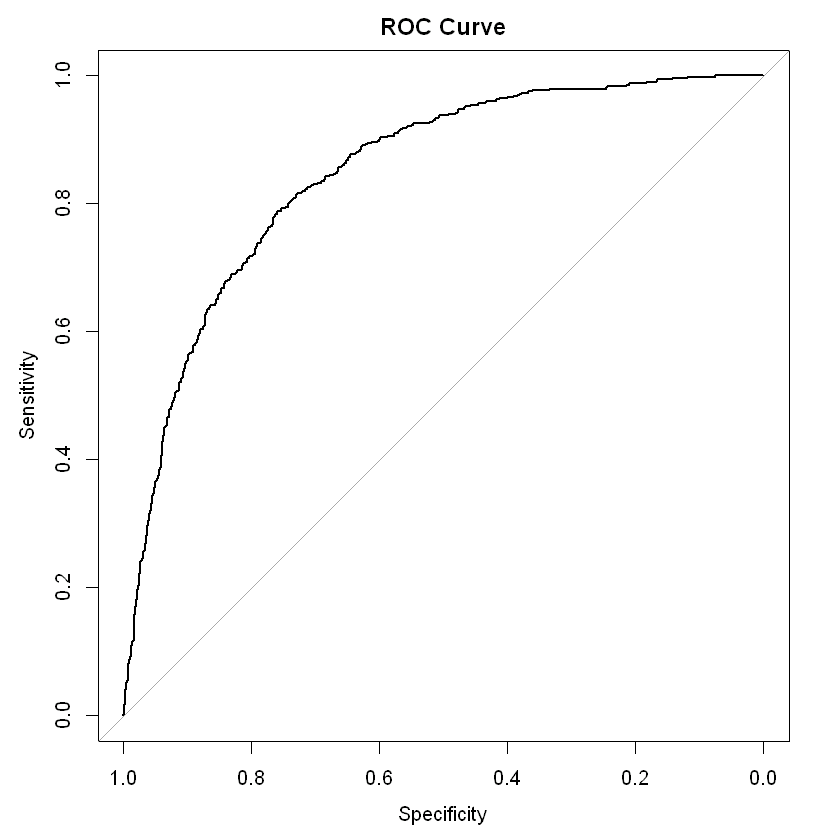

In [59]:
roc_curve <- roc(testing$Churn, prob_test)
plot(roc_curve, main = "ROC Curve")
auc(roc_curve)

# 10. Conclusions

The refined model (13 predictors, AUC = 0.846) achieves good discriminatory performance and a coherent business narrative — with no meaningful loss in predictive power over the full 19-predictor model.

**Key business implications:**

1. **Contract strategy**: Month-to-month customers are the highest-risk segment. Targeted incentives to migrate them to annual contracts could meaningfully reduce churn.
2. **Fibre optic service**: The strong positive association with churn likely reflects unmet service quality expectations. This is worth investigating via customer satisfaction data.
3. **Early tenure is critical**: New customers churn at much higher rates. An onboarding programme targeting customers in their first 6–12 months could be high-ROI.
4. **Retention offers for high-charge, short-tenure customers** — this profile combines high churn risk with high revenue potential, making them the priority segment for personalised retention.